# Model 3 — Scheme Fit Scorer

Computes how well a player's shot selection and play-type tendencies align with a team's offensive system.

**Feature space:**

| Layer | Dims | Player source | Team source | Coverage |
|---|---|---|---|---|
| Base (shot distribution) | 3 | `player_season_stats` | `team_style_vectors.parquet` | 100% |
| Extended (HE play-types) | 6 | `hoop_explorer_player_stats` | `team_style_vectors.parquet` | ~15% players, ~82% teams |

`scheme_fit` in DB = 3-dim base cosine, consistent for all pairs (used for cross-pair ranking).  
`he_scheme_fit` added to `breakdown` JSON for HE-covered pairs (supplementary, not used in ranking).  
`pace_match` computed from `adj_tempo` delta between player's current school and candidate school.

**Output:** `player_team_fit_scores` — every eligible player×school pair (scheme-cos-v3, no top-k truncation) — matches Gap Matching's all-pairs scope so both models share the same player×school universe.

**Prerequisites:**
- `feature_eng_m1_m2_m3.ipynb` complete → `data/features/team_style_vectors.parquet` (includes HE cols)
- `team_clustering.ipynb` complete → `team_system_profiles` in DB
- `player_season_stats` + `hoop_explorer_player_stats` populated in DB

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from datetime import datetime, timedelta, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from psycopg2.extras import execute_values
from sklearn.metrics.pairwise import cosine_similarity
from sqlalchemy import create_engine, text

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.3f}'.format)
print('imports OK')

imports OK


In [ ]:
# ── Config — pulled from src/portalpoint/modeling/scheme_fit.py ─────────────────
from portalpoint.modeling import scheme_fit as sf
from portalpoint.modeling.io import find_repo_root, get_sync_engine

MODEL_VERSION = sf.MODEL_VERSION
EXPIRES_DAYS  = sf.EXPIRES_DAYS
SCHOOL_CHUNK_SIZE = 50  # bounds memory for the all-pairs score+write loop (Section 4)

PLAYER_SHOT_FEATS = sf.PLAYER_SHOT_FEATS
TEAM_SHOT_FEATS   = sf.TEAM_SHOT_FEATS
HE_FEATS          = sf.HE_FEATS

W_GAP    = sf.W_GAP
W_SCHEME = sf.W_SCHEME
W_OPP    = sf.W_OPP
W_PERS   = sf.W_PERS

_root = find_repo_root()
FEATURES_DIR = _root / 'data' / 'features'

engine = get_sync_engine()
print('Repo root    :', _root)
print('Connected    :', engine.url.render_as_string(hide_password=True))
print(f'Model version: {MODEL_VERSION}  ({len(MODEL_VERSION)} chars)')


## 1. Load Data

In [3]:
# ── Team style vectors (from feature_eng_m1_m2_m3.ipynb parquet) ──────────────
# Parquet is pooled across all seasons — keep all for multi-season scoring.
team_df = pq.read_table(FEATURES_DIR / 'team_style_vectors.parquet').to_pandas()
SEASONS_IN_DATA = sorted(team_df['season'].unique().tolist())
CURRENT_SEASON  = max(SEASONS_IN_DATA)
team_df = team_df.dropna(subset=TEAM_SHOT_FEATS)

# Deduplicate (school_id, season) — feature_eng parquet may produce duplicate rows
# from multi-source joins; keep first occurrence
n_before = len(team_df)
team_df = team_df.drop_duplicates(subset=['school_id', 'season'], keep='first').reset_index(drop=True)
if len(team_df) < n_before:
    print(f'  Dropped {n_before - len(team_df):,} duplicate (school_id, season) rows from parquet')

# Pre-compute per-row HE coverage flag — used in the scoring loop
if all(f in team_df.columns for f in HE_FEATS):
    team_df['_he_covered'] = team_df[HE_FEATS].notna().all(axis=1)
else:
    print('WARNING: HE columns not found in parquet — run feature_eng_m1_m2_m3.ipynb first')
    for f in HE_FEATS:
        team_df[f] = np.nan
    team_df['_he_covered'] = False

# Validate shot rates are proportions (0-1)
for f in TEAM_SHOT_FEATS:
    assert team_df[f].between(0, 1).all(), f'{f} has values outside [0, 1]'

print(f'Seasons in parquet: {SEASONS_IN_DATA}')
print(f'Team-seasons total: {len(team_df):,}')
for s, g in team_df.groupby('season'):
    n_he = int(g['_he_covered'].sum())
    print(f'  {s}: {len(g):,} teams  HE={n_he:,} ({n_he/len(g):.0%})')

team_df[TEAM_SHOT_FEATS + ['adj_tempo', 'adj_em']].describe().round(3)

Seasons in parquet: [2021, 2022, 2023, 2024, 2025, 2026]


Team-seasons total: 2,158
  2021: 346 teams  HE=326 (94%)
  2022: 358 teams  HE=343 (96%)
  2023: 363 teams  HE=352 (97%)
  2024: 362 teams  HE=352 (97%)
  2025: 364 teams  HE=356 (98%)
  2026: 365 teams  HE=357 (98%)


,team_three_rate,team_rim_rate,team_mid_rate,adj_tempo,adj_em
count,2158.000,2158.000,2158.000,1812.000,1812.000
mean,0.359,0.392,0.249,67.365,0.001
std,0.057,0.052,0.061,2.427,12.197
min,0.194,0.237,0.069,58.712,-42.241
25%,0.321,0.356,0.207,65.713,-8.641
50%,0.357,0.391,0.250,67.326,-1.357
75%,0.397,0.426,0.289,68.983,8.357
max,0.563,0.560,0.462,75.103,38.554


In [4]:
# ── Merge Model 2 system labels from DB into team_df (all seasons) ────────────
with engine.connect() as conn:
    labels_df = pd.read_sql(
        text('SELECT school_id, season, cluster_id, system_label FROM team_system_profiles WHERE season = ANY(:seasons)'),
        conn,
        params={'seasons': SEASONS_IN_DATA},
    )

team_df = team_df.merge(labels_df, on=['school_id', 'season'], how='left')
missing = team_df['system_label'].isna().sum()
if missing:
    print(f'WARNING: {missing}/{len(team_df)} team-seasons have no system label (Model 2 not run or season mismatch)')
    team_df['system_label'] = team_df['system_label'].fillna('Unknown')
    team_df['cluster_id']   = team_df['cluster_id'].fillna(-1).astype(int)
else:
    print(f'System labels merged: {len(team_df):,} team-seasons, {team_df["system_label"].nunique()} distinct systems')
print(team_df.groupby('season')['system_label'].count().rename('teams_with_labels').to_string())

System labels merged: 2,158 team-seasons, 42 distinct systems
season
2021    346
2022    358
2023    363
2024    362
2025    364
2026    365


In [5]:
# ── Player shot distribution (all seasons, season-matched to team data) ────────
PLAYER_SQL = """
SELECT
    pss.player_id,
    pss.season,
    pss.school_id,
    p.full_name,
    pss.three_point_rate,
    pss.rim_rate,
    pss.mid_range_rate,
    pss.usage_rate,
    pss.games_played,
    pss.min_pct
FROM player_season_stats pss
JOIN players p ON p.id = pss.player_id
WHERE pss.season = ANY(:seasons)
  AND pss.three_point_rate IS NOT NULL
  AND pss.rim_rate         IS NOT NULL
  AND pss.mid_range_rate   IS NOT NULL
  AND pss.games_played >= 5
"""

with engine.connect() as conn:
    player_df = pd.read_sql(text(PLAYER_SQL), conn, params={'seasons': SEASONS_IN_DATA})

print(f'Player-seasons loaded (raw): {len(player_df):,}')

# Validate: clip out-of-range shot rates
for f in PLAYER_SHOT_FEATS:
    bad = (~player_df[f].between(0, 1)).sum()
    if bad:
        print(f'  WARNING: {bad} rows have {f} outside [0, 1] — clipping')
        player_df[f] = player_df[f].clip(0, 1)

# Drop rows where all 3 rates are 0 (invalid data)
zero_mask = (player_df[PLAYER_SHOT_FEATS].sum(axis=1) == 0)
player_df = player_df[~zero_mask]

# Deduplicate (player_id, season) — mid-season transfers have 2 rows per season;
# keep the row with the most games played so the upsert constraint is never violated.
n_before = len(player_df)
player_df = (
    player_df
    .sort_values('games_played', ascending=False)
    .drop_duplicates(subset=['player_id', 'season'], keep='first')
    .reset_index(drop=True)
)
n_dupes = n_before - len(player_df)
if n_dupes:
    print(f'  Dropped {n_dupes:,} duplicate (player_id, season) rows (mid-season transfers)')

for s, g in player_df.groupby('season'):
    print(f'  {s}: {len(g):,} player-seasons')

# ── Season-matched current-school tempo join ──────────────────────────────────
# Player's tempo context = their school's tempo in the same season
tempo_lookup = (
    team_df[['school_id', 'season', 'adj_tempo']]
    .rename(columns={'adj_tempo': 'current_tempo'})
)
player_df = player_df.merge(tempo_lookup, on=['school_id', 'season'], how='left')
TEMPO_DEFAULT = float(team_df['adj_tempo'].median())
n_missing_tempo = int(player_df['current_tempo'].isna().sum())
if n_missing_tempo:
    print(f'  {n_missing_tempo} player-seasons lack current-school tempo — using median {TEMPO_DEFAULT:.1f}')
player_df['current_tempo'] = player_df['current_tempo'].fillna(TEMPO_DEFAULT)

player_df[PLAYER_SHOT_FEATS].describe().round(3)

Player-seasons loaded (raw): 26,862
  2021: 4,239 player-seasons
  2022: 4,503 player-seasons
  2023: 4,521 player-seasons
  2024: 4,532 player-seasons
  2025: 4,541 player-seasons
  2026: 4,525 player-seasons
  4239 player-seasons lack current-school tempo — using median 67.3


,three_point_rate,rim_rate,mid_range_rate
count,26861.000,26861.000,26861.000
mean,0.375,0.391,0.233
std,0.256,0.230,0.145
min,0.000,0.000,0.000
25%,0.167,0.222,0.134
50%,0.382,0.357,0.220
75%,0.556,0.538,0.314
max,1.000,1.000,1.000


In [6]:
# ── HE player play-type frequencies (extended scheme fit, all seasons) ─────────
HE_PLAYER_SQL = """
SELECT
    he.player_id,
    he.season,
    he.off_style_transition_pct,
    he.off_style_post_up_pct,
    he.off_style_pick_pop_pct,
    he.off_style_big_cut_roll_pct,
    he.off_style_attack_kick_pct,
    he.off_style_perimeter_cut_pct
FROM hoop_explorer_player_stats he
WHERE he.season = ANY(:seasons)
  AND he.player_id IS NOT NULL
"""

with engine.connect() as conn:
    he_player_raw = pd.read_sql(text(HE_PLAYER_SQL), conn, params={'seasons': SEASONS_IN_DATA})

print(f'HE player records loaded: {len(he_player_raw):,}  seasons={sorted(he_player_raw["season"].unique())}')

# Season-matched join — (player_id, season)
player_df = player_df.merge(he_player_raw, on=['player_id', 'season'], how='left')
player_df = player_df.reset_index(drop=True)

print(f'\nPlayer-seasons total: {len(player_df):,}')
for s, g in player_df.groupby('season'):
    n_he = int(g[HE_FEATS].notna().all(axis=1).sum())
    print(f'  {s}: {len(g):,} players  HE={n_he:,} ({n_he/len(g):.0%})')

HE player records loaded: 16,206  seasons=[np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Player-seasons total: 26,863
  2021: 4,240 players  HE=2,477 (58%)
  2022: 4,504 players  HE=2,638 (59%)
  2023: 4,521 players  HE=2,658 (59%)
  2024: 4,532 players  HE=2,714 (60%)
  2025: 4,541 players  HE=2,757 (61%)
  2026: 4,525 players  HE=2,801 (62%)


## 2. Scheme Fit Computation

**Cosine similarity on shot distribution:**  
Both player and team vectors live in the same 3-dim space (3PT, rim, mid).  
Since all values ≥ 0, cosine similarity ∈ [0, 1] → scale to [0, 100].

**Sub-component breakdown:**  
Per-dimension similarity computed as `max(0, 1 - |player_rate - team_rate| / range)`.  
Gives an interpretable per-feature match score used in the UI breakdown card.

In [7]:
# Feature range for sub-component scaling (observed data range, min 0.1 to avoid div-by-zero)
scheme_fit_score = sf.scheme_fit_score
scheme_breakdown = sf.scheme_breakdown
_RANGE = sf.feature_ranges(player_df, team_df)

# HE feature ranges — computed from covered subsets only
he_player_mask = player_df[HE_FEATS].notna().all(axis=1).values
he_team_mask = team_df['_he_covered'].values
he_p_idx = np.where(he_player_mask)[0]
he_t_idx  = np.where(he_team_mask)[0]
if len(he_p_idx) > 0 and len(he_t_idx) > 0:
    _HE_RANGE = {}
    for f in HE_FEATS:
        lo = min(player_df.iloc[he_p_idx][f].min(), team_df.iloc[he_t_idx][f].min())
        hi = max(player_df.iloc[he_p_idx][f].max(), team_df.iloc[he_t_idx][f].max())
        _HE_RANGE[f] = max(hi - lo, 0.05)
else:
    _HE_RANGE = {f: 1.0 for f in HE_FEATS}

print('Shot distribution ranges:')
for pf, r in _RANGE.items():
    print(f'  {pf:<20s}: {r:.3f}')


# Sanity check
_p_3pt = np.array([0.50, 0.30, 0.20])
_t_3pt = np.array([0.48, 0.32, 0.20])
_t_rim = np.array([0.25, 0.55, 0.20])
print(f'\n3PT player vs 3PT team : {scheme_fit_score(_p_3pt, _t_3pt):.1f}')
print(f'3PT player vs Rim team : {scheme_fit_score(_p_3pt, _t_rim):.1f}')
print('(higher = better fit, expected: first > second)')


Shot distribution ranges:
  three_point_rate    : 1.000
  rim_rate            : 1.000
  mid_range_rate      : 1.000

3PT player vs 3PT team : 99.9
3PT player vs Rim team : 84.1
(higher = better fit, expected: first > second)


In [8]:
# ── Current-season matrices for validation (Section 3) ────────────────────────
# Multi-season scoring happens in Section 4. These matrices exist for spot-checks only.
p_cur = player_df[player_df['season'] == CURRENT_SEASON].reset_index(drop=True)
t_cur = team_df[team_df['season'] == CURRENT_SEASON].reset_index(drop=True)

P_cur = p_cur[PLAYER_SHOT_FEATS].values.astype(np.float64)
T_cur = t_cur[TEAM_SHOT_FEATS].values.astype(np.float64)
SIM_SCALED = np.clip(cosine_similarity(P_cur, T_cur) * 100, 0, 100)

T_TEMPO_cur   = t_cur['adj_tempo'].values
P_TEMPO_cur   = p_cur['current_tempo'].values
TEMPO_RANGE   = max(float(T_TEMPO_cur.max() - T_TEMPO_cur.min()), 1.0)
PACE_MATCH = np.clip(
    (1.0 - np.abs(P_TEMPO_cur[:, None] - T_TEMPO_cur[None, :]) / TEMPO_RANGE) * 100,
    0.0, 100.0,
)

# HE matrices for current season (validation only)
he_p_mask_cur = p_cur[HE_FEATS].notna().all(axis=1).values
he_t_mask_cur = t_cur['_he_covered'].values
n_he_p_cur = int(he_p_mask_cur.sum())
n_he_t_cur = int(he_t_mask_cur.sum())
if n_he_p_cur > 0 and n_he_t_cur > 0:
    HE_SIM = np.clip(
        cosine_similarity(
            p_cur[HE_FEATS].values[he_p_mask_cur].astype(np.float64),
            t_cur[HE_FEATS].values[he_t_mask_cur].astype(np.float64),
        ) * 100, 0, 100,
    )
    print(f'HE matrix ({CURRENT_SEASON}): {HE_SIM.shape}  mean={HE_SIM.mean():.1f}  std={HE_SIM.std():.1f}')
else:
    HE_SIM = np.empty((0, 0))
    print('HE sim matrix: empty — check HE ingest')

print(f'\nCurrent-season ({CURRENT_SEASON}) base similarity: {SIM_SCALED.shape}')
print(f'Mean: {SIM_SCALED.mean():.2f}  Std: {SIM_SCALED.std():.2f}  Min/Max: {SIM_SCALED.min():.2f}/{SIM_SCALED.max():.2f}')
print(f'Pace match — mean: {PACE_MATCH.mean():.1f}  std: {PACE_MATCH.std():.1f}')

# Feature ranges (used by scheme_breakdown helper — global across full player/team population)
_RANGE = {}
for pf, tf in zip(PLAYER_SHOT_FEATS, TEAM_SHOT_FEATS):
    lo = min(player_df[pf].min(), team_df[tf].min())
    hi = max(player_df[pf].max(), team_df[tf].max())
    _RANGE[pf] = max(hi - lo, 0.10)

HE matrix (2026): (2801, 357)  mean=78.7  std=16.8



Current-season (2026) base similarity: (4525, 365)
Mean: 85.63  Std: 11.76  Min/Max: 10.39/100.00
Pace match — mean: 77.9  std: 16.4


## 3. Validation

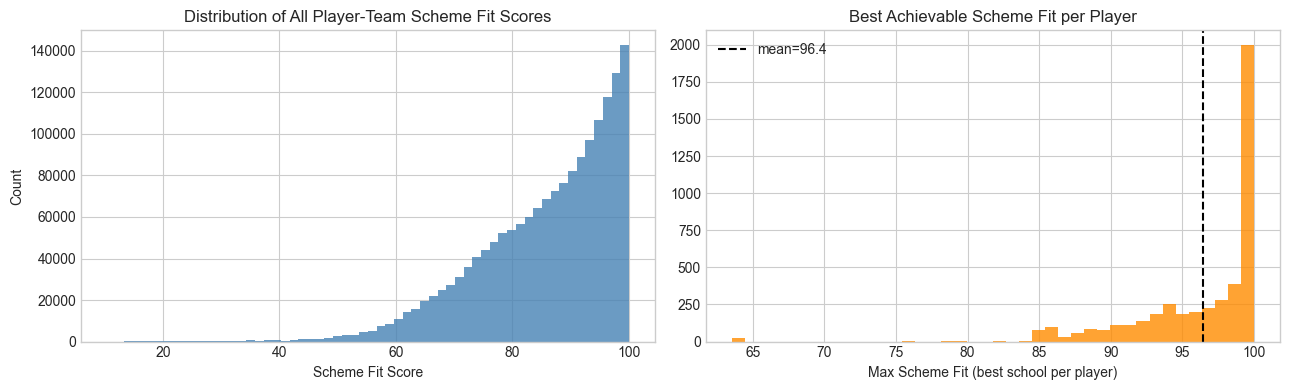

Players with best fit >= 95: 3,171
Players with best fit <  70: 23


In [9]:
# Distribution of scheme_fit scores
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(SIM_SCALED.flatten(), bins=60, edgecolor='none', color='steelblue', alpha=0.8)
axes[0].set_xlabel('Scheme Fit Score'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of All Player-Team Scheme Fit Scores')

# Per-player max score distribution (best achievable fit per player)
max_fits = SIM_SCALED.max(axis=1)
axes[1].hist(max_fits, bins=40, edgecolor='none', color='darkorange', alpha=0.8)
axes[1].set_xlabel('Max Scheme Fit (best school per player)')
axes[1].set_title('Best Achievable Scheme Fit per Player')
axes[1].axvline(max_fits.mean(), linestyle='--', color='black', label=f'mean={max_fits.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Players with best fit >= 95: {(max_fits >= 95).sum():,}')
print(f'Players with best fit <  70: {(max_fits <  70).sum():,}')

In [10]:
# Spot-check: top-5 and bottom-5 schools for 5 sample players (current season)
SAMPLE_N = 5
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(p_cur), size=SAMPLE_N, replace=False)

for i in sample_idx:
    p = p_cur.iloc[i]
    scores = SIM_SCALED[i]
    top5_idx = np.argsort(scores)[::-1][:5]
    bot5_idx = np.argsort(scores)[:5]

    print(f'\nPlayer: {p.full_name} (3PT={p.three_point_rate:.2f}, Rim={p.rim_rate:.2f}, Mid={p.mid_range_rate:.2f})')
    print('  Top-5 fits:')
    for j in top5_idx:
        t = t_cur.iloc[j]
        print(f'    {t.school_name:<22s} {t.conference:<5s}  fit={scores[j]:.1f}'
              f'  (3PT={t.team_three_rate:.2f}, Rim={t.team_rim_rate:.2f})')
    print('  Bottom-5 fits:')
    for j in bot5_idx:
        t = t_cur.iloc[j]
        print(f'    {t.school_name:<22s} {t.conference:<5s}  fit={scores[j]:.1f}'
              f'  (3PT={t.team_three_rate:.2f}, Rim={t.team_rim_rate:.2f})')


Player: Sebastian Mack (3PT=0.28, Rim=0.42, Mid=0.30)
  Top-5 fits:
    Cal St. Bakersfield    BW     fit=100.0  (3PT=0.28, Rim=0.42)
    Southern Illinois      MVC    fit=100.0  (3PT=0.28, Rim=0.43)
    St. Bonaventure        A10    fit=100.0  (3PT=0.28, Rim=0.43)
    Eastern Illinois       OVC    fit=100.0  (3PT=0.28, Rim=0.44)
    Delaware St.           MEAC   fit=100.0  (3PT=0.29, Rim=0.42)
  Bottom-5 fits:
    Wisconsin              B10    fit=84.8  (3PT=0.56, Rim=0.30)
    Alabama                SEC    fit=85.8  (3PT=0.55, Rim=0.34)
    Louisville             ACC    fit=88.0  (3PT=0.52, Rim=0.38)
    Cal Poly               BW     fit=88.5  (3PT=0.49, Rim=0.44)
    VMI                    SC     fit=89.2  (3PT=0.51, Rim=0.34)

Player: C.J. Booker (3PT=0.40, Rim=0.21, Mid=0.38)
  Top-5 fits:
    Houston                B12    fit=99.4  (3PT=0.41, Rim=0.26)
    UTEP                   CUSA   fit=98.0  (3PT=0.41, Rim=0.29)
    Purdue                 B10    fit=97.9  (3PT=0.38, Rim=0.31

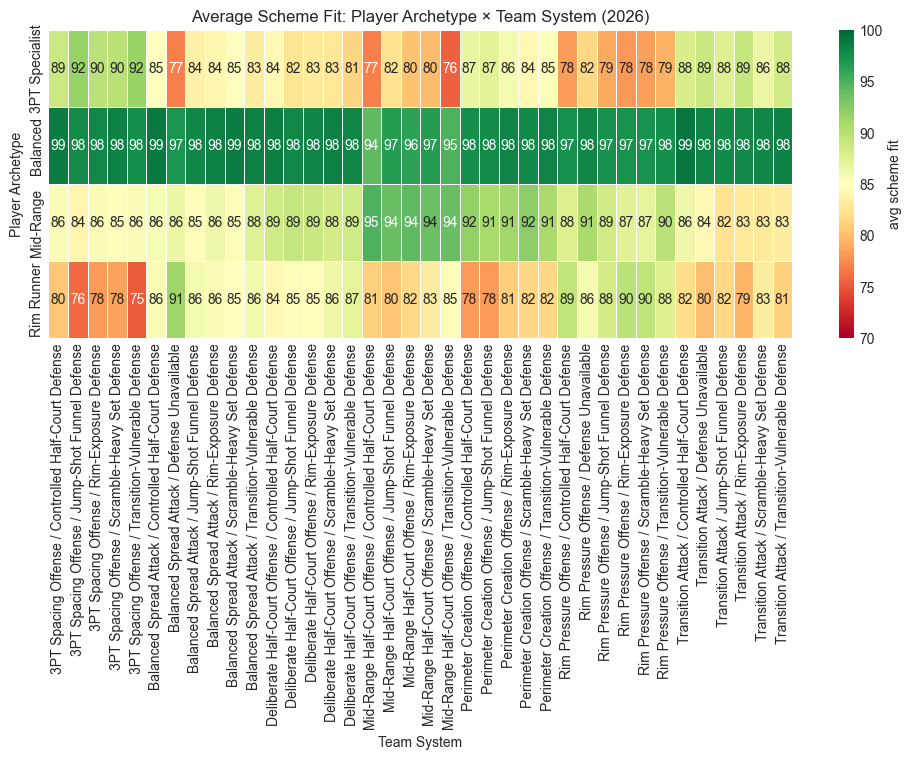

In [11]:
# Heatmap: average scheme fit by player shot archetype vs. team system cluster (current season)
def _shot_archetype(row):
    if row.three_point_rate >= 0.45:  return '3PT Specialist'
    if row.rim_rate >= 0.47:          return 'Rim Runner'
    if row.mid_range_rate >= 0.28:    return 'Mid-Range'
    return 'Balanced'

p_cur = p_cur.copy()
p_cur['shot_arch'] = p_cur.apply(_shot_archetype, axis=1)

heatmap_data = []
for p_arch in p_cur['shot_arch'].unique():
    p_idx = p_cur[p_cur['shot_arch'] == p_arch].index
    p_scores = SIM_SCALED[p_idx, :]
    for j, (_, t_row) in enumerate(t_cur.iterrows()):
        heatmap_data.append({'p_arch': p_arch, 'system': t_row.get('system_label', f'C{j}'),
                              'fit': p_scores[:, j].mean()})

hm = pd.DataFrame(heatmap_data)
if 'system_label' in t_cur.columns:
    pivot = hm.groupby(['p_arch', 'system'])['fit'].mean().unstack().round(1)
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', vmin=70, vmax=100,
                linewidths=0.5, ax=ax, cbar_kws={'label': 'avg scheme fit'})
    ax.set_title(f'Average Scheme Fit: Player Archetype × Team System ({CURRENT_SEASON})')
    ax.set_xlabel('Team System'); ax.set_ylabel('Player Archetype')
    plt.tight_layout()
    plt.show()
else:
    print('system_label not in t_cur — run Model 2 first')

## 4. Score + Write All Pairs (scheme-cos-v3)

Scores every eligible player×school pair, season-matched — no top-k truncation. Processed in school-id chunks of `SCHOOL_CHUNK_SIZE` per season, written chunk-by-chunk: all-pairs across 2021-2026 is too large to hold as a single in-memory `records` list. Mirrors `scripts/run_scheme_fit.py` exactly, including the full-season delete done once up front (`sf.delete_season_rows`) before any chunk is written.

In [ ]:
# ── Score + write all pairs, per-season school-chunk loop (scheme-cos-v3) ───────
deleted = sf.delete_season_rows(engine, SEASONS_IN_DATA)
print(f'Deleted {deleted:,} stale rows for seasons {SEASONS_IN_DATA}')

total_records = 0
total_upserted = 0
total_he = 0
sim_sum = 0.0
sim_sq_sum = 0.0
season_stats: dict[int, dict] = {}

for season in SEASONS_IN_DATA:
    school_ids = sorted(team_df.loc[team_df['season'] == season, 'school_id'].unique().tolist())
    season_records = 0
    season_upserted = 0
    season_he = 0
    season_sim_sum = 0.0
    for start in range(0, len(school_ids), SCHOOL_CHUNK_SIZE):
        school_batch = school_ids[start:start + SCHOOL_CHUNK_SIZE]
        records, _, n_he = sf.score_all_seasons(
            player_df, team_df, [season], TEMPO_DEFAULT,
            school_ids=school_batch, model_version=MODEL_VERSION,
        )
        if not records:
            continue
        sim_values = np.fromiter((r[5] for r in records), dtype=np.float64, count=len(records))
        total_records += len(records); season_records += len(records)
        total_he += n_he; season_he += n_he
        sim_sum += float(sim_values.sum()); season_sim_sum += float(sim_values.sum())
        sim_sq_sum += float(np.square(sim_values).sum())
        upserted = sf.upsert_fit_scores(engine, records)
        total_upserted += upserted; season_upserted += upserted

    n_players_season = int((player_df['season'] == season).sum())
    season_stats[season] = {
        'n_players': n_players_season,
        'n_teams': len(school_ids),
        'mean_fit': season_sim_sum / season_records if season_records else float('nan'),
        'n_he': season_he,
    }
    print(f"Season {season}: {season_stats[season]['n_players']:,}p x {season_stats[season]['n_teams']:,}t -> "
          f"{season_records:,} records  HE={season_he:,}  upserted={season_upserted:,}")

print(f'\nTotal records: {total_records:,}  HE records: {total_he:,}')
print(f'Total upserted: {total_upserted:,}')

expires_at = datetime.now(timezone.utc) + timedelta(days=EXPIRES_DAYS)  # display only — each record carries its own


## 5. Verification

The write already happened chunk-by-chunk in Section 4 — this just confirms the resulting DB state.

In [ ]:
# ── Verify ───────────────────────────────────────────────────────────────────
with engine.connect() as conn:
    row = conn.execute(text(
        'SELECT COUNT(*), ROUND(AVG(scheme_fit)::numeric, 2) FROM player_team_fit_scores'
    )).fetchone()
    by_season = conn.execute(text(
        'SELECT season, COUNT(*) FROM player_team_fit_scores GROUP BY season ORDER BY season'
    )).fetchall()
print(f'DB total rows: {row[0]:,}  avg scheme_fit: {row[1]}')
for s, n in by_season:
    print(f'  {s}: {n:,} rows')


## 6. On-Demand Computation Function

Used by `fit_scores.py` router for pairs not in the pre-computed cache.

In [14]:
compute_scheme_fit_ondemand = sf.compute_scheme_fit_ondemand

# Smoke test 1: nearly perfect match, tempo supplied
r1 = compute_scheme_fit_ondemand(
    player_three=0.45, player_rim=0.35, player_mid=0.20,
    team_three=0.46,   team_rim=0.34,   team_mid=0.20,
    feat_ranges=_RANGE, tempo_range=TEMPO_RANGE,
    player_tempo=68.0, team_tempo=69.0,
)
print('Test 1 (near-perfect match, tempo):')
print(f'  scheme_fit: {r1["scheme_fit"]}  (expect > 98)')
print(f'  breakdown : {r1["breakdown"]}')

# Smoke test 2: 3PT player → rim team, fast player → slow team, with HE vectors
r2 = compute_scheme_fit_ondemand(
    player_three=0.50, player_rim=0.30, player_mid=0.20,
    team_three=0.25,   team_rim=0.55,   team_mid=0.20,
    feat_ranges=_RANGE, tempo_range=TEMPO_RANGE,
    player_tempo=72.0, team_tempo=63.0,
    player_he=[0.25, 0.05, 0.08, 0.15, 0.30, 0.17],  # transition-heavy player
    team_he=  [0.08, 0.25, 0.18, 0.22, 0.12, 0.15],  # post-heavy team
)
print('\nTest 2 (style mismatch, tempo mismatch, HE mismatch):')
print(f'  scheme_fit   : {r2["scheme_fit"]}  (expect < 80)')
print(f'  pace_match   : {r2["breakdown"]["pace_match"]}  (expect low — 72 vs 63 poss/40)')
print(f'  he_scheme_fit: {r2["breakdown"].get("he_scheme_fit")}  (expect lower than base)')


Test 1 (near-perfect match, tempo):
  scheme_fit: 99.97  (expect > 98)
  breakdown : {'three_point_match': 99.0, 'rim_attack_match': 99.0, 'pace_match': 91.6, 'usage_match': 50.0, 'ball_movement_match': 100.0}

Test 2 (style mismatch, tempo mismatch, HE mismatch):
  scheme_fit   : 84.12  (expect < 80)
  pace_match   : 24.6  (expect low — 72 vs 63 poss/40)
  he_scheme_fit: 71.0  (expect lower than base)


In [ ]:
print('=' * 58)
print('MODEL 3 — SCHEME FIT SCORER SUMMARY')
print('=' * 58)
print(f'Seasons scored  : {SEASONS_IN_DATA}  (season-matched pairs)')
print(f'Model version   : {MODEL_VERSION}')
print(f'Total records   : {total_records:,}  (all eligible player x school pairs, no top-k)')
print(f'Expires         : {expires_at.date()} ({EXPIRES_DAYS} days)')
print()
print('Per-season breakdown:')
for s, st in season_stats.items():
    print(f'  {s}: {st["n_players"]:,}p × {st["n_teams"]:,}t  mean_fit={st["mean_fit"]:.1f}  HE={st["n_he"]:,}')
print()
print(f'Total HE-extended records: {total_he:,}')
print()
print('Breakdown components:')
print('  scheme_fit    : REAL — 3-dim shot cosine (all pairs)')
print('  pace_match    : REAL — adj_tempo delta, season-matched')
print('  he_scheme_fit : REAL — 6-dim HE play-type cosine (HE-covered pairs only)')
print('  usage_match   : STUB (50.0) — needs Model 4 output')
print('  gap_match     : STUB (50.0) — overwritten with real values once Gap Matching runs next')
print('  role_fit      : STUB (50.0) — needs Model 4 output')
print('  program_fit   : STUB (50.0)')

## 7. MLflow Tracking

In [ ]:
import sys

import mlflow
import mlflow.pyfunc
from portalpoint.modeling.mlflow_helpers import setup_mlflow, maybe_promote

EXPERIMENT    = 'scheme-fit-scorer'
MODEL_NAME    = 'scheme-fit-scorer'
ARTIFACT_PATH = 'scheme_fit_model'


class SchemeFitPyfunc(mlflow.pyfunc.PythonModel):
    """Wraps scheme fit cosine computation for MLflow model registry.

    Input DataFrame columns:
        player_three, player_rim, player_mid, team_three, team_rim, team_mid
    Output: list of dicts with 'scheme_fit' key (float 0-100).
    """

    def predict(self, context, model_input):
        import numpy as np
        results = []
        for _, r in model_input.iterrows():
            p = np.array([r.player_three, r.player_rim, r.player_mid], dtype=np.float64)
            t = np.array([r.team_three,   r.team_rim,   r.team_mid],   dtype=np.float64)
            norm_p, norm_t = np.linalg.norm(p), np.linalg.norm(t)
            if norm_p == 0 or norm_t == 0:
                sf_score = 50.0
            else:
                sf_score = float(np.clip(np.dot(p, t) / (norm_p * norm_t) * 100, 0, 100))
            results.append({'scheme_fit': round(sf_score, 2)})
        return results


client = setup_mlflow(EXPERIMENT)

# Stats come from Section 4's incremental accumulation, not SIM_SCALED (that's
# current-season-only, validation-scoped) — all-pairs across 2021-2026 is too
# large to hold as one in-memory matrix/DataFrame.
_mean_sf   = sim_sum / total_records
_std_sf    = float(np.sqrt(max(sim_sq_sum / total_records - _mean_sf * _mean_sf, 0.0)))
_n_records = total_records

with mlflow.start_run(run_name=f'scheme-fit-s{CURRENT_SEASON}') as run:
    mlflow.log_params({
        'seasons':       ','.join(str(s) for s in SEASONS_IN_DATA),
        'feature_dims':  len(PLAYER_SHOT_FEATS),
        'features':      ','.join(PLAYER_SHOT_FEATS),
        'sim_method':    'cosine',
        'model_version': MODEL_VERSION,
    })
    mlflow.log_metrics({
        'mean_scheme_fit':   _mean_sf,
        'std_scheme_fit':    _std_sf,
        'n_records_written': float(_n_records),
        'n_players':         float(len(player_df)),
        'n_teams':           float(len(team_df)),
    })

    mlflow.pyfunc.log_model(
        artifact_path=ARTIFACT_PATH,
        python_model=SchemeFitPyfunc(),
    )

    run_id = run.info.run_id

# Promotion metric: std_scheme_fit, not n_records_written.
# Record count barely changes run to run regardless of model quality — it was
# a meaningless comparison that would promote almost any rerun. std is the
# right signal here: known issue is score compression (cosine sim on
# non-negative proportions summing to ~1 clusters scores near 100), so a
# genuine improvement (e.g. M3 v3 with hoopR spatial zones) should widen the
# distribution, not just rerun the same pipeline on the same row count.
result = maybe_promote(
    client, MODEL_NAME, run_id, ARTIFACT_PATH,
    metric_name='std_scheme_fit',
    new_value=_std_sf,
    higher_is_better=True,
)
print(f'Run ID  : {run_id}')
print(f'Registry: {result}')
